# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

---

Justification:

Total param count of $\text{FFN}_\text{GLU}$: $2 * d_\text{model} * d_\text{ff}$

Total param count of $\text{FFN}_\text{GEGLU}$: $W + V + W_2 = 3 * d_\text{model} * d_\text{ff}'$ 

Thus, to keep the comparison fair, use the $\frac{2}{3}$ width rule from Shazeer: $d_\text{ff}' = \frac{2}{3} d_\text{ff}$.

---

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [1]:
from __future__ import annotations

import time
import random
from dataclasses import dataclass, field, replace

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# these are not hparams actually used, only test constants
B = 4
C = 1
H = W = 28
P = 4
D = 4
D_ff = 16
N = C * H * W // (P**2 * C)
N_heads = 2
N_layers = 2
dropout = 0.1
num_classes = 10

In [3]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # TODO: Implement a tokenization strategy
    # x: (B, C, H, W)
    # returns (B, N, P^2 * C)
    B, C, H, W = x.shape
    P = patch_size
    assert H % P == 0 and W % P == 0

    nH, nW = H // P, W // P
    x = x.reshape(B, C, nH, P, nW, P)
    # -> (B, nH, nW, P, P, C)
    x = x.permute(0, 2, 4, 3, 5, 1)
    # -> (B, nH * nW, P * P * C)
    x = x.reshape(B, nH * nW, P**2 * C)
    return x.contiguous()


assert patchify(torch.randn(B, 1, H, W), P).shape == (
    B,
    (C * H * W) // P**2,
    P**2 * C,
)

In [4]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        # patch_dim = P*P*C
        # d_model = D
        self.pte = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        # x_patches: (B, N, P*P*C)
        return self.pte(x_patches)  # (B, N, d_model)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        # num_tokens = N
        # d_model = D
        self.ppe = nn.Parameter(torch.zeros(1, num_tokens, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, N, d_model)
        return x + self.ppe  # (B, N, d_model)


assert PatchEmbed(P**2 * C, D)(torch.randn(B, N, P**2 * C)).shape == (B, N, D)
assert PositionalEmbedding(N, D)(torch.randn(B, N, D)).shape == (B, N, D)

In [5]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.w_up = nn.Linear(d_model, d_ff, bias=False)
        self.gelu = nn.GELU()
        self.drop_1 = nn.Dropout(dropout)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        self.drop_2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.w_up(x)
        x = self.gelu(x)
        x = self.drop_1(x)
        x = self.w_down(x)
        x = self.drop_2(x)
        return x


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""

    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        # combine gate and up projection into one matmul
        self.w_gate_up = nn.Linear(d_model, 2 * d_ff_gated, bias=False)
        self.drop_1 = nn.Dropout(dropout)
        self.w_down = nn.Linear(d_ff_gated, d_model, bias=False)
        self.drop_2 = nn.Dropout(dropout)
        match variant:
            case "GLU":
                self.act = nn.Sigmoid()
            case "Bilinear":
                self.act = nn.Identity()
            case "ReGLU":
                self.act = nn.ReLU()
            case "GEGLU":
                self.act = nn.GELU()
            case "SwiGLU":
                self.act = nn.SiLU()
            case _:
                raise ValueError("Invalid GLU FFW variant")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate_up_proj = self.w_gate_up(x)
        gate, up = gate_up_proj.chunk(2, dim=-1)
        x_gated = up * self.act(gate)
        x_gated = self.drop_1(x_gated)
        out = self.w_down(x_gated)
        out = self.drop_2(out)
        return out


assert FeedForward(D, D_ff, dropout)(torch.randn(B, N, D)).shape == (B, N, D)
assert GLUFeedForward(D, D_ff, dropout, "SwiGLU")(torch.randn(B, N, D)).shape == (
    B,
    N,
    D,
)

In [6]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """

    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout, batch_first=True)
        self.ln_2 = nn.LayerNorm(d_model)
        self.mlp = mlp
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, N, D)
        # returns (B, N, D)
        x = self.ln_1(x)
        x_attn, _ = self.mha(query=x, key=x, value=x, need_weights=False)
        x = x + x_attn
        x = x + self.drop(self.mlp(self.ln_2(x)))
        return x


assert TransformerEncoderBlock(D, N_heads, FeedForward(D, D_ff, dropout), dropout)(
    torch.randn(B, N, D)
).shape == (B, N, D)

In [7]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """

    def __init__(
        self,
        img_shape: tuple[int, int, int],
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
        num_classes: int,
    ):
        super().__init__()
        # TODO: implement a strategy for embedding the patches
        self.patch_size = patch_size
        C, H, W = img_shape
        P = patch_size
        assert H % P == 0 and W % P == 0
        patch_dim = P**2 * C
        num_tokens = (C * H * W) // P**2
        self.patch_embed = nn.Sequential(
            PatchEmbed(patch_dim, d_model), PositionalEmbedding(num_tokens, d_model)
        )

        # TODO: implement a strategy to select the right mlp version for your experiment
        def build_mlp(d_model: int, d_ff: int, dropout: float, mlp_kind: str):
            match mlp_kind:
                case "Standard":
                    return FeedForward(d_model, d_ff, dropout)
                case "GLU" | "Bilinear" | "ReGLU" | "GEGLU" | "SwiGLU":
                    d_ff_gated = int(2 / 3 * d_ff)
                    return GLUFeedForward(d_model, d_ff_gated, dropout, mlp_kind)
                case _:
                    raise ValueError("Invalid MLP kind")

        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    d_model=d_model,
                    n_heads=n_heads,
                    mlp=build_mlp(
                        d_model, d_ff, dropout, mlp_kind
                    ),  # TODO: Feed your mlp to the encoder blocks
                    dropout=dropout,
                )
                for _ in range(n_layers)
            ]
        )

        # TODO: Add a head to project to the amount of output classes you have
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        # returns (B, num_classses)
        patches = patchify(x, self.patch_size)  # (B, N, P^2 * C)
        tokens = self.patch_embed(patches)  # (B, N, D)
        for block in self.blocks:
            logits = block(tokens)  # (B, N, D)
        logits = logits.mean(-2)  # (B, D)
        logits = self.head(logits)  # (B, num_classes)
        return logits


assert TinyViT(
    (C, H, W), P, D, N_heads, N_layers, D_ff, dropout, "SwiGLU", num_classes
)(torch.randn(B, C, H, W)).shape == (B, num_classes)

In [8]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: torch.device = torch.device("cpu")


@dataclass(frozen=True)
class TrainOutput:
    seed: int
    model_params: int
    train_losses: list[float] = field(default_factory=list)
    test_accs: list[float] = field(default_factory=list)

In [9]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> TrainOutput:
    model.to(cfg.device)
    opt = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )

    train_losses: list[float] = []
    step_times: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):
        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            t0 = time.perf_counter()
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()
            t1 = time.perf_counter()
            step_times.append(t1 - t0)

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(
            f"[{mlp_kind}] epoch {epoch + 1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f} | step time: {sum(step_times[-len(train_loader) :]) / len(train_loader):.4f}s"
        )

    return TrainOutput(
        cfg.seed, sum(p.numel() for p in model.parameters()), train_losses, test_accs
    )

In [10]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
assert device is not None
cfg = TrainConfig(
    seed=0,
    batch_size=128,
    epochs=5,
    lr=3e-4,
    weight_decay=0.01,
    device=device,
)
tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0
)

# Tiny model example. TODO: You're welcome to experiment with these parameters
seeds = [0, 1, 2]
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

img_shape = (1, 28, 28)
num_classes = 10

runs = [
    "Standard",
    "GLU",
    "GEGLU",
]  # TODO: Name your runs
results = {k: [] for k in runs}

for kind in runs:
    for seed in seeds:
        cfg = replace(cfg, seed=seed)
        torch.manual_seed(seed)
        random.seed(seed)
        model = TinyViT(
            img_shape=img_shape,
            patch_size=patch_size,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff=d_ff,
            dropout=dropout,
            mlp_kind=kind,
            num_classes=num_classes,
        )
        # TODO: print anything you might want here
        print(f"\nRun: {kind} | Seed: {seed}")
        out = train_one_run(kind, model, train_loader, test_loader, cfg)
        results[kind].append(out)


Run: Standard | Seed: 0
[Standard] epoch 1/5 | test acc: 0.7328 | step time: 0.0055s
[Standard] epoch 2/5 | test acc: 0.8753 | step time: 0.0050s
[Standard] epoch 3/5 | test acc: 0.9013 | step time: 0.0050s
[Standard] epoch 4/5 | test acc: 0.9139 | step time: 0.0050s
[Standard] epoch 5/5 | test acc: 0.9225 | step time: 0.0049s

Run: Standard | Seed: 1
[Standard] epoch 1/5 | test acc: 0.7264 | step time: 0.0049s
[Standard] epoch 2/5 | test acc: 0.8535 | step time: 0.0049s
[Standard] epoch 3/5 | test acc: 0.8860 | step time: 0.0050s
[Standard] epoch 4/5 | test acc: 0.9088 | step time: 0.0050s
[Standard] epoch 5/5 | test acc: 0.9186 | step time: 0.0050s

Run: Standard | Seed: 2
[Standard] epoch 1/5 | test acc: 0.7571 | step time: 0.0049s
[Standard] epoch 2/5 | test acc: 0.8584 | step time: 0.0050s
[Standard] epoch 3/5 | test acc: 0.8902 | step time: 0.0050s
[Standard] epoch 4/5 | test acc: 0.9021 | step time: 0.0050s
[Standard] epoch 5/5 | test acc: 0.9060 | step time: 0.0050s

Run: GLU 

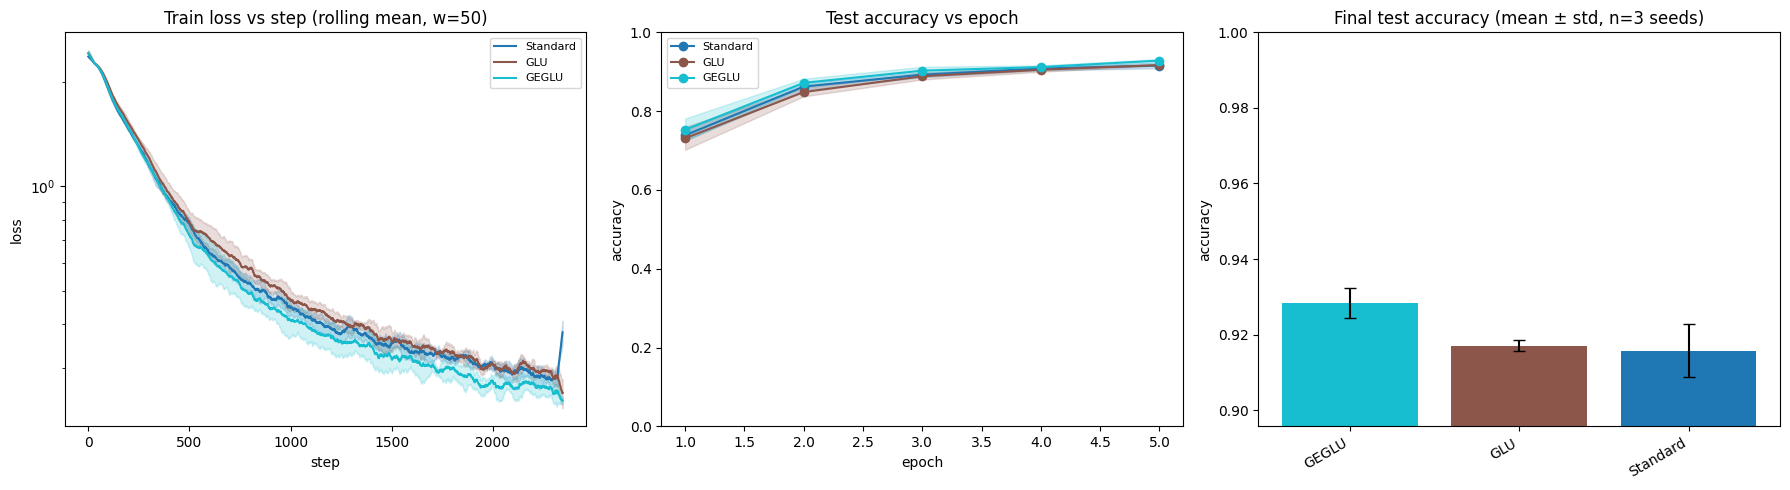


variant        params   final acc (mean±std)    best acc (mean±std)
------------------------------------------------------------------
Standard       104202 0.9157±0.0070        0.9157±0.0070
GLU            103946 0.9171±0.0015        0.9171±0.0015
GEGLU          103946 0.9283±0.0039        0.9283±0.0039


In [11]:
import matplotlib.pyplot as plt
import numpy as np

VARIANTS = list(results.keys())
COLORS = plt.cm.tab10(np.linspace(0, 1, len(VARIANTS)))


def _stack(vals: list[list[float]]) -> np.ndarray:
    return np.stack([np.asarray(v, dtype=float) for v in vals])  # (seeds, steps)


def _rolling(a: np.ndarray, w: int) -> np.ndarray:
    """Per-row rolling mean with edge padding (same length)."""
    out = np.empty_like(a)
    for i, row in enumerate(a):
        pad = w // 2
        padded = np.pad(row, pad, mode="edge")
        kernel = np.ones(w) / w
        out[i] = np.convolve(padded, kernel, mode="valid")[: len(row)]
    return out


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: train loss vs step (smoothed, mean ± std over seeds) ---
ax = axes[0]
for c, kind in zip(COLORS, VARIANTS):
    outs = results[kind]
    loss = _rolling(_stack([o.train_losses for o in outs]), w=50)  # (seeds, steps)
    mean, std = loss.mean(0), loss.std(0)
    steps = np.arange(len(mean))
    ax.plot(steps, mean, color=c, label=kind)
    ax.fill_between(steps, mean - std, mean + std, color=c, alpha=0.2)
ax.set_title("Train loss vs step (rolling mean, w=50)")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend(fontsize=8)
ax.set_yscale("log")

# --- Plot 2: test acc vs epoch (mean ± std over seeds) ---
ax = axes[1]
for c, kind in zip(COLORS, VARIANTS):
    outs = results[kind]
    acc = _stack([o.test_accs for o in outs])  # (seeds, epochs)
    mean, std = acc.mean(0), acc.std(0)
    epochs = np.arange(1, len(mean) + 1)
    ax.plot(epochs, mean, color=c, marker="o", label=kind)
    ax.fill_between(epochs, mean - std, mean + std, color=c, alpha=0.2)
ax.set_title("Test accuracy vs epoch")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# --- Plot 3: final test acc bar chart with error bars, sorted best -> worst ---
ax = axes[2]
final_mean = {k: np.mean([o.test_accs[-1] for o in results[k]]) for k in VARIANTS}
final_std = {k: np.std([o.test_accs[-1] for o in results[k]]) for k in VARIANTS}
order = sorted(VARIANTS, key=lambda k: final_mean[k], reverse=True)
bars = [final_mean[k] for k in order]
errs = [final_std[k] for k in order]
colors = [COLORS[VARIANTS.index(k)] for k in order]
ax.bar(range(len(order)), bars, yerr=errs, color=colors, capsize=4)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_title("Final test accuracy (mean ± std, n=%d seeds)" % len(seeds))
ax.set_ylabel("accuracy")
ax.set_ylim(min(bars) - 0.02, 1.0)

plt.tight_layout()
plt.show()

# --- Summary table ---
print(
    f"\n{'variant':<10} {'params':>10} {'final acc (mean±std)':>22} {'best acc (mean±std)':>22}"
)
print("-" * 66)
for kind in VARIANTS:
    outs = results[kind]
    params = outs[0].model_params
    finals = np.array([o.test_accs[-1] for o in outs])
    bests = np.array([max(o.test_accs) for o in outs])
    print(
        f"{kind:<10} {params:>10d} "
        f"{finals.mean():.4f}±{finals.std():.4f}        "
        f"{bests.mean():.4f}±{bests.std():.4f}"
    )